In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('/home/moraa-ontita/Documents/Machine-learning/talent_survey/artifacts/cleaned/cleaned_dataset.csv')

In [3]:
df.head(10)

,ObjectId,Data_Set_Name,Brief_Description_of_Data,Data_Source,Home_Department,Home_Department_Division,Data_Steward__Business__Name,Data_Custodian__Technical__Name,Data_Classification,Data_Format,Frequency_of_Data_Change,Time_Span,Geographic_Coverage,Geographic_Granularity,Link_to_Existing_Publication
0,1,Meter,"Meter Information, location type, rates etc",Meter Bagging,Parking Authority Of River City,Unspecified,Not listed,Not listed,Public,Access Consolidated Database,Continuous,Unknown,Citywide,Not applicable,No link available
1,2,Property Maintenance Cases,No description provided,Hansen 8,Codes & Regulations,Property Maintenance Division,Benjamin Anderson,Not listed,Public,Csv File,Not updated (historical only),5 Years,Citywide,Latitude/longitude;#Street address,https://data.louisvilleky.gov/dataset/property...
2,3,Order Meter,Data on orders with meter information,Meter Bagging,Parking Authority Of River City,Unspecified,Not listed,Not listed,Public,Access Consolidated Database,Continuous,2007 to present,Citywide,Not applicable,No link available
3,4,Meter Order Summary,​Order centric data for Meter Bagging,Unknown,Parking Authority Of River City,On Street,Not listed,Not listed,Public,Unknown,Continuous,2007 to present,Citywide,Not applicable,No link available
4,5,Passport Transaction Detail,No description provided,Passport (Go502),Parking Authority Of River City,Unspecified,Not listed,Not listed,Internal,Excel Spread Sheets,Continuous,Unknown,Citywide,Not applicable,No link available
5,6,Palm Audit Data,​Information on collections for Palm meters. C...,Palm,Parking Authority Of River City,Unspecified,Not listed,Not listed,Public,Csv File,Continuous,Unknown,Citywide,Not applicable,No link available
6,7,Hub Revenue,​Revenue information for garage transients(tic...,Hub,Parking Authority Of River City,Unspecified,Not listed,Not listed,Internal,Text File Delimited,Continuous,Updated per transaction,Citywide,Not applicable,No link available
7,8,Ballparc,​Data concerning sales for events.,Ballparc,Parking Authority Of River City,Unspecified,Not listed,Not listed,Internal,Other,Continuous,Unknown,Citywide,Not applicable,No link available
8,9,Umojo Daily Activity,​Details on call activity for Parc Operations ...,Umojo,Parking Authority Of River City,Unspecified,Not listed,Not listed,Internal,Excel Spread Sheets,Continuous,2018-Today,Citywide,Not applicable,No link available
9,10,Restaurant Inspection Data,"​Restaurant inspection dates, grades, scores a...",Ehmis-Environmental Health Management Informat...,Public Health & Wellness,Environmental Services,Kelly Monahan,Gerald Kaforski,Public,Flat File,Monthly,Unknown,Citywide,Latitude/longitude,https://data.louisvilleky.gov/dataset/restaura...


# Analysis

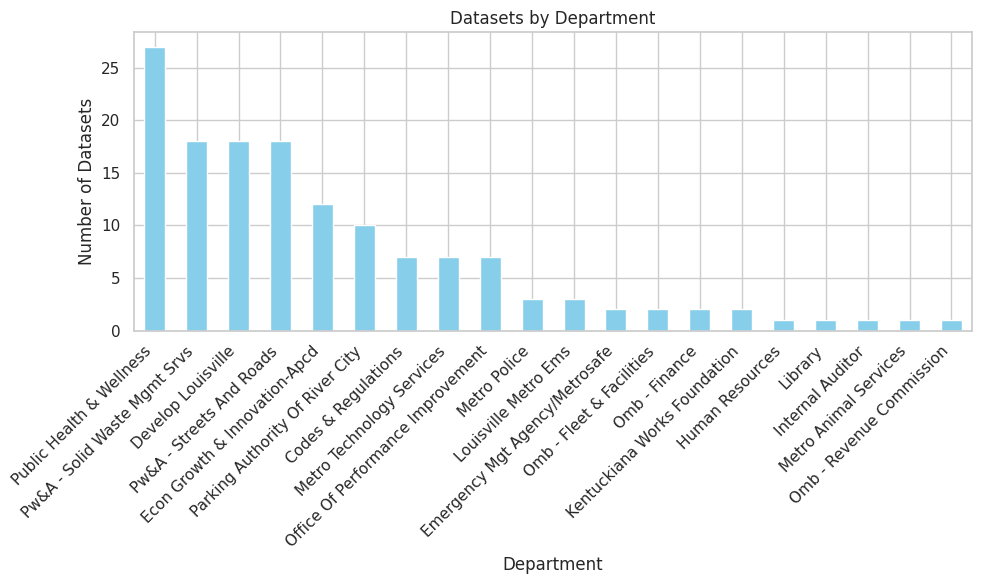

In [5]:
# Set a consistent plot style
sns.set(style="whitegrid")
plt.rcParams.update({'figure.figsize': (10, 6)})

# Datasets by Department
dept_counts = df['Home_Department'].value_counts()
dept_counts.plot(kind='bar', title='Datasets by Department', color='skyblue')
plt.xlabel('Department')
plt.ylabel('Number of Datasets')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

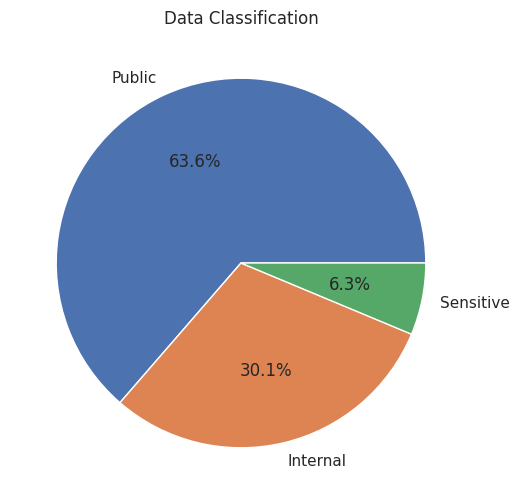

In [6]:
#Public vs. Internal datasets
classification_counts = df['Data_Classification'].value_counts()
classification_counts.plot(kind='pie', autopct='%1.1f%%', title='Data Classification')
plt.ylabel('')
plt.show()

/tmp/ipykernel_973731/2322946932.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=format_counts.values, y=format_counts.index, palette='pastel')


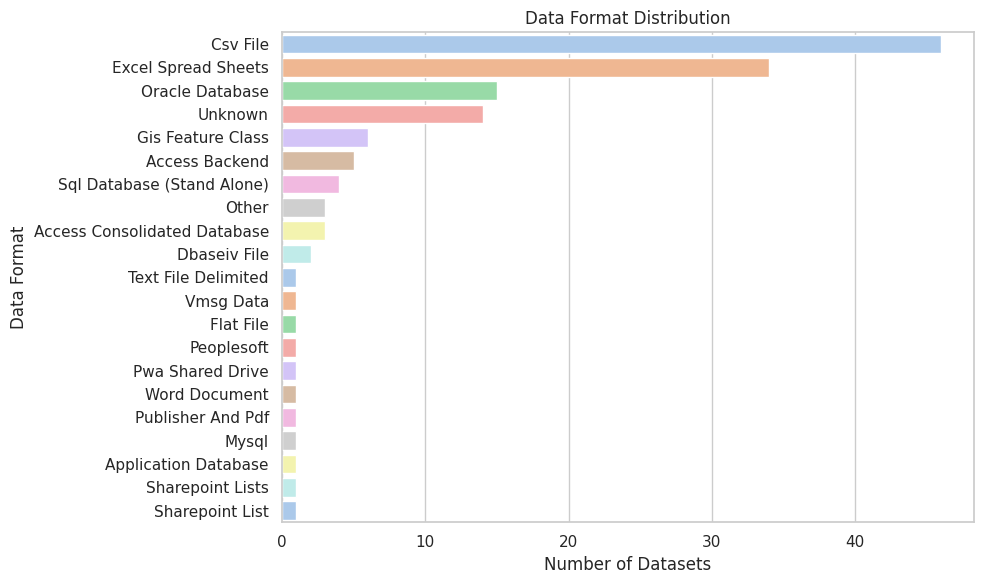

In [7]:
# Dataset Format Distribution
format_counts = df['Data_Format'].value_counts()
sns.barplot(x=format_counts.values, y=format_counts.index, palette='pastel')
plt.title('Data Format Distribution')
plt.xlabel('Number of Datasets')
plt.ylabel('Data Format')
plt.tight_layout()
plt.show()

/tmp/ipykernel_973731/225634509.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=freq_counts.values, y=freq_counts.index, palette='muted')


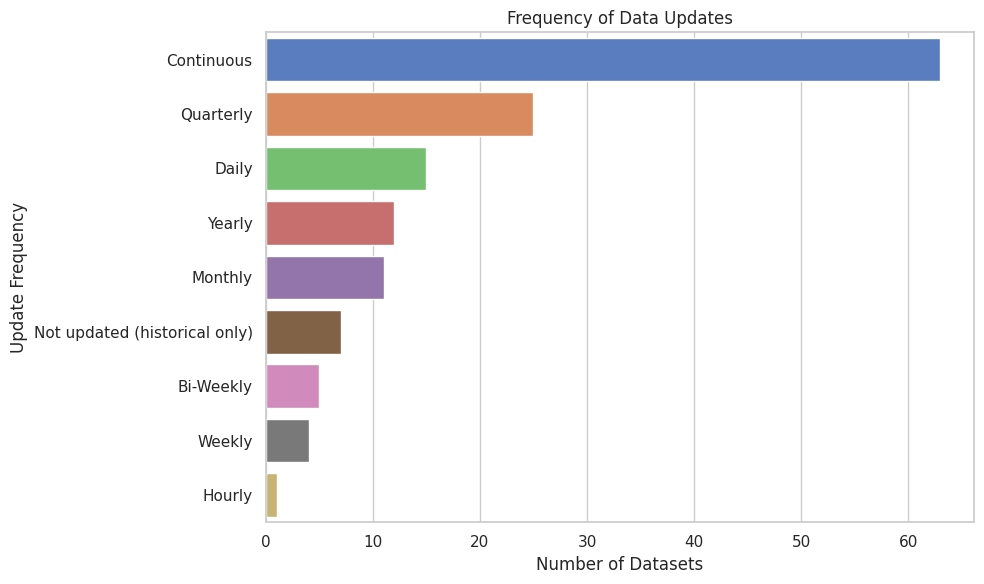

In [8]:
# Data Update Frequency
freq_counts = df['Frequency_of_Data_Change'].value_counts()
sns.barplot(x=freq_counts.values, y=freq_counts.index, palette='muted')
plt.title('Frequency of Data Updates')
plt.xlabel('Number of Datasets')
plt.ylabel('Update Frequency')
plt.tight_layout()
plt.show()

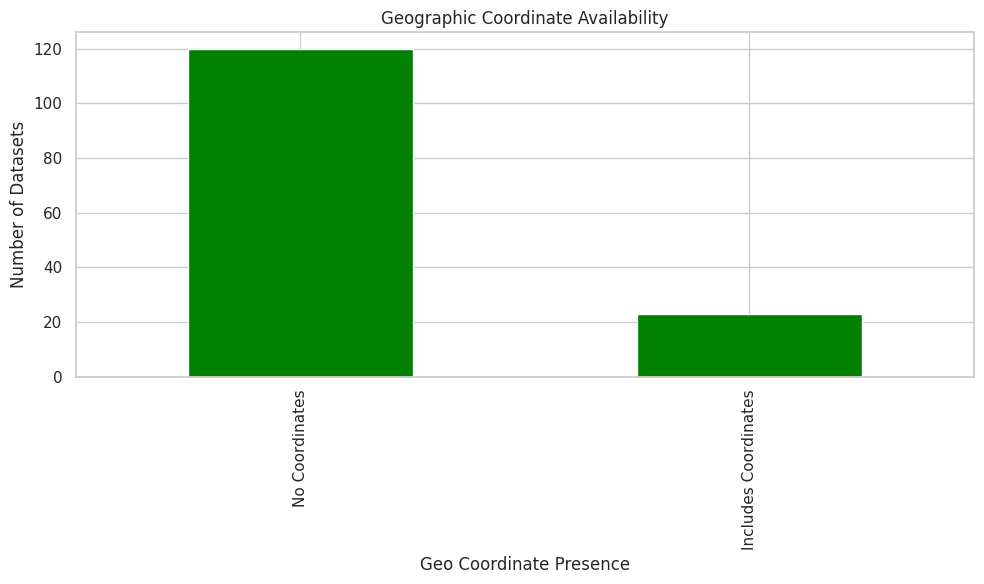

In [9]:
# Datasets with vs without Geographic Coordinates
geo_coord = df['Geographic_Granularity'].fillna('').apply(lambda x: 'Includes Coordinates' if 'latitude' in x.lower() or 'longitude' in x.lower() else 'No Coordinates')
geo_coord.value_counts().plot(kind='bar', color='green')
plt.title('Geographic Coordinate Availability')
plt.xlabel('Geo Coordinate Presence')
plt.ylabel('Number of Datasets')
plt.tight_layout()
plt.show()

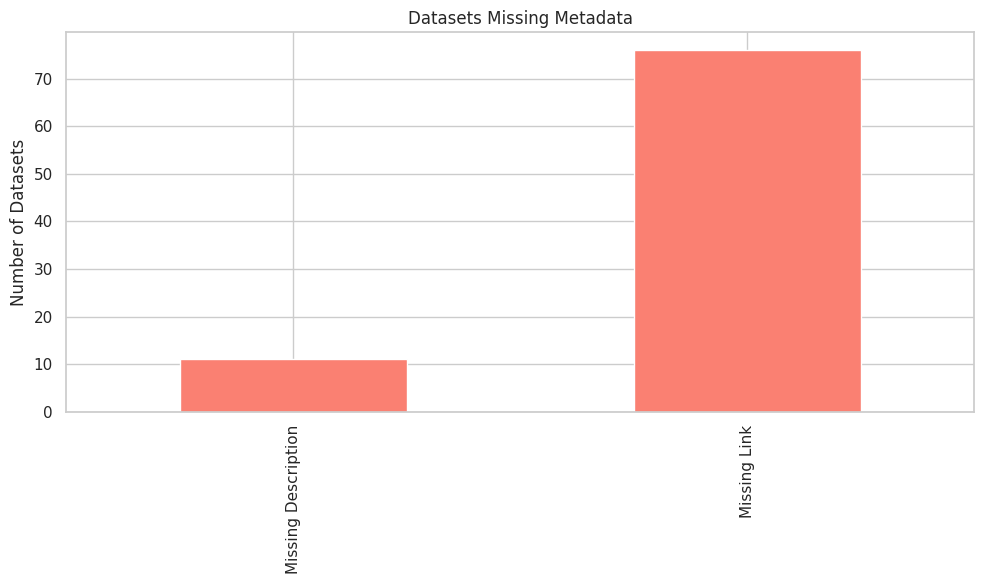

In [10]:
# Datasets with Missing Descriptions or Links
missing_desc = df['Brief_Description_of_Data'].isnull() | df['Brief_Description_of_Data'].str.lower().str.contains('no description')
missing_link = df['Link_to_Existing_Publication'].isnull() | df['Link_to_Existing_Publication'].str.lower().str.contains('no link')
missing_summary = pd.Series({'Missing Description': missing_desc.sum(), 'Missing Link': missing_link.sum()})
missing_summary.plot(kind='bar', color='salmon')
plt.title('Datasets Missing Metadata')
plt.ylabel('Number of Datasets')
plt.tight_layout()
plt.show()

/tmp/ipykernel_973731/3630142967.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=time_span_counts.values, y=time_span_counts.index, palette='coolwarm')


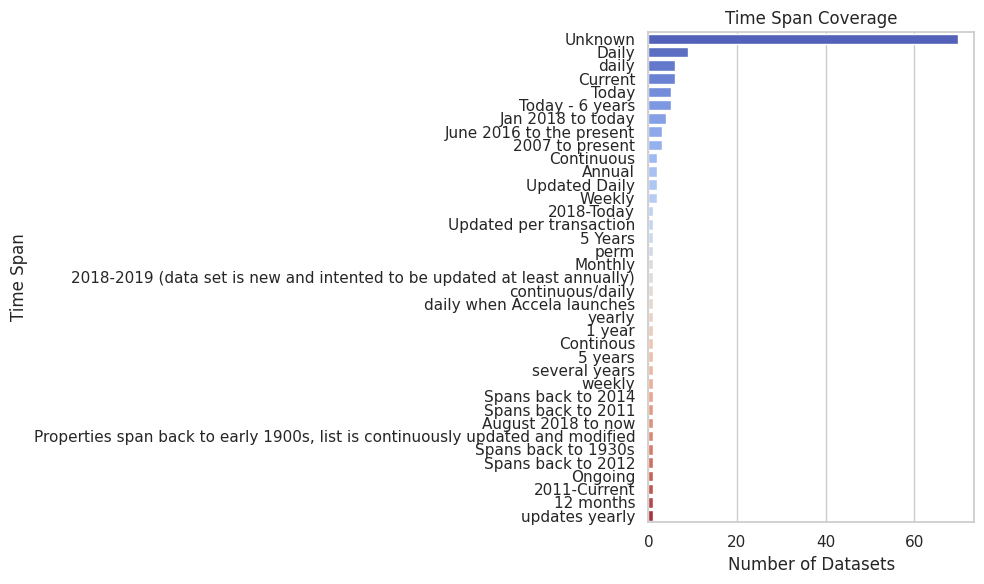

In [11]:
# Time Span Overview
time_span_counts = df['Time_Span'].fillna('Unknown').value_counts()
sns.barplot(x=time_span_counts.values, y=time_span_counts.index, palette='coolwarm')
plt.title('Time Span Coverage')
plt.xlabel('Number of Datasets')
plt.ylabel('Time Span')
plt.tight_layout()
plt.show()